In [1]:
# Standard imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Helpful extra functionality
from scipy import special
from typing import List, Dict, Optional
import mpl_toolkits.mplot3d as m3d

# Important functionality for this lesson
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# Setting globally figure size in the notebook
plt.rcParams["figure.figsize"] = (8.0, 6.0)

  ### EXPLORATORY DATA ANALYSIS OF DISTRIBUTED CUSTOMER PURCHASING DATA

In [3]:
# Read in the data
superstore_df = pd.read_csv(r"C:\Users\raust\OneDrive\Documents\0BrainStation\BrainStation_DataScience\Week22_IndustrySprint2\Datasets\superstore.csv\superstore.csv")
superstore_df.head()


,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [4]:
len(superstore_df)

51290

In [8]:
# Check for and remove NULL values
superstore_df.isna().sum() 
# There were no NULLS

Category          0
City              0
Country           0
Customer.ID       0
Customer.Name     0
Discount          0
Market            0
记录数               0
Order.Date        0
Order.ID          0
Order.Priority    0
Product.ID        0
Product.Name      0
Profit            0
Quantity          0
Region            0
Row.ID            0
Sales             0
Segment           0
Ship.Date         0
Ship.Mode         0
Shipping.Cost     0
State             0
Sub.Category      0
Year              0
Market2           0
weeknum           0
dtype: int64

In [9]:
# Check for and remove duplicate values
superstore_df.duplicated(keep='first').sum() #total # of duplicated rows 
# There were no duplicates
# superstore_df.drop_duplicates(keep='first', inplace=True) # Not necessary

0

In [28]:
superstore_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [104]:
country_counts = superstore_df["Country"].value_counts()
country_counts

country_unique = superstore_df["Country"].unique()
nation_df = pd.DataFrame({
    'Nation': country_unique
})

counts_df = pd.DataFrame({
    'Country Counts': country_counts
})

counts_df.head()
# Produce heat map of global map

,Country Counts
Country,
United States,9994
Australia,2837
France,2827
Mexico,2644
Germany,2065


In [131]:
counts = superstore_df["Country"].value_counts()
counts
counts_df = counts.reset_index()
counts_df.columns = ["Country", "Count"]
counts_df

,Country,Count
0,United States,9994
1,Australia,2837
2,France,2827
3,Mexico,2644
4,Germany,2065
...,...,...
142,South Sudan,2
143,Chad,2
144,Swaziland,2
145,Eritrea,2


In [80]:
# Verify which countries have customer representation
superstore_df["Country"].unique()

array(['United States', 'France', 'Germany', 'El Salvador', 'Guatemala',
       'Austria', 'Nicaragua', 'Belgium', 'Switzerland', 'Italy',
       'South Africa', 'India', 'Hong Kong',
       'Democratic Republic of the Congo', 'Cuba', 'United Kingdom',
       'Spain', 'Russia', 'China', 'Niger', 'Qatar', 'New Zealand',
       'Mexico', 'Malaysia', 'Poland', 'Madagascar', 'Iraq', 'Brazil',
       'Colombia', 'Saudi Arabia', 'Egypt', 'Iran', 'Ukraine', 'Japan',
       'Morocco', 'Cameroon', 'Chile', 'Ghana', 'Trinidad and Tobago',
       'Canada', 'Chad', 'Kenya', 'Bangladesh', 'Bulgaria', 'Djibouti',
       'Uruguay', 'Singapore', 'Czech Republic', 'Zambia', 'Bolivia',
       'Angola', 'Australia', 'Tanzania', 'Norway', 'Sierra Leone',
       'Hungary', 'Ecuador', 'Finland', 'Afghanistan', 'Uzbekistan',
       'Romania', 'Kyrgyzstan', 'Belarus', 'Mongolia', 'Georgia', 'Syria',
       'Croatia', 'Israel', 'Liberia', 'Guinea-Bissau', 'Somalia',
       'Senegal', 'Tunisia', 'Mali', 'Algeri

In [132]:
# Prepare the data to plot a geographic heat map showing global distribution of customers
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load built-in world map data from GeoPandas
world = gpd.read_file(r"C:\Users\raust\OneDrive\Documents\0BrainStation\BrainStation_DataScience\Week22_IndustrySprint2\Datasets\ne_110m_admin_0_countries\ne_110m_admin_0_countries.shp")


# Match country names between data sets before merging.
counts_df["Country"] = counts_df["Country"].replace("United States", "United States of America")
counts_df["Country"] = counts_df["Country"].replace("Tanzania", "United Republic of Tanzania")
counts_df["Country"] = counts_df["Country"].replace("Myanmar (Burma)", "Myanmar")
counts_df["Country"] = counts_df["Country"].replace("Czech Republic", "Czechia")
counts_df["Country"] = counts_df["Country"].replace("Cote d'Ivoire", "Ivory Coast")

# Merge the data with the world GeoDataFrame in order to produce geographic heatmap
world_data = world.merge(counts_df, how="left", left_on="SOVEREIGNT", right_on="Country")

world_data


,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry,Country,Count
0,Admin-0 country,1,6,Fiji,FJI,0,2,Sovereign country,1,Fiji,...,None,None,None,None,None,None,None,"MULTIPOLYGON (((180 -16.06713, 180 -16.55522, ...",NaN,NaN
1,Admin-0 country,1,3,United Republic of Tanzania,TZA,0,2,Sovereign country,1,United Republic of Tanzania,...,None,None,None,None,None,None,None,"POLYGON ((33.90371 -0.95, 34.07262 -1.05982, 3...",United Republic of Tanzania,148.0
2,Admin-0 country,1,7,Western Sahara,SAH,0,2,Indeterminate,1,Western Sahara,...,Unrecognized,None,None,Unrecognized,None,None,None,"POLYGON ((-8.66559 27.65643, -8.66512 27.58948...",NaN,NaN
3,Admin-0 country,1,2,Canada,CAN,0,2,Sovereign country,1,Canada,...,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -122.97421 49.0025...",Canada,384.0
4,Admin-0 country,1,2,United States of America,US1,1,2,Country,1,United States of America,...,None,None,None,None,None,None,None,"MULTIPOLYGON (((-122.84 49, -120 49, -117.0312...",United States of America,9994.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,Admin-0 country,1,5,Republic of Serbia,SRB,0,2,Sovereign country,1,Republic of Serbia,...,None,None,None,None,None,None,None,"POLYGON ((18.82982 45.90887, 18.82984 45.90888...",NaN,NaN
173,Admin-0 country,1,6,Montenegro,MNE,0,2,Sovereign country,1,Montenegro,...,None,None,None,None,None,None,None,"POLYGON ((20.0707 42.58863, 19.80161 42.50009,...",Montenegro,4.0
174,Admin-0 country,1,6,Kosovo,KOS,0,2,Disputed,1,Kosovo,...,Admin-0 country,Unrecognized,Admin-0 country,Admin-0 country,Admin-0 country,Admin-0 country,Unrecognized,"POLYGON ((20.59025 41.85541, 20.52295 42.21787...",NaN,NaN
175,Admin-0 country,1,5,Trinidad and Tobago,TTO,0,2,Sovereign country,1,Trinidad and Tobago,...,None,None,None,None,None,None,None,"POLYGON ((-61.68 10.76, -61.105 10.89, -60.895...",Trinidad and Tobago,30.0


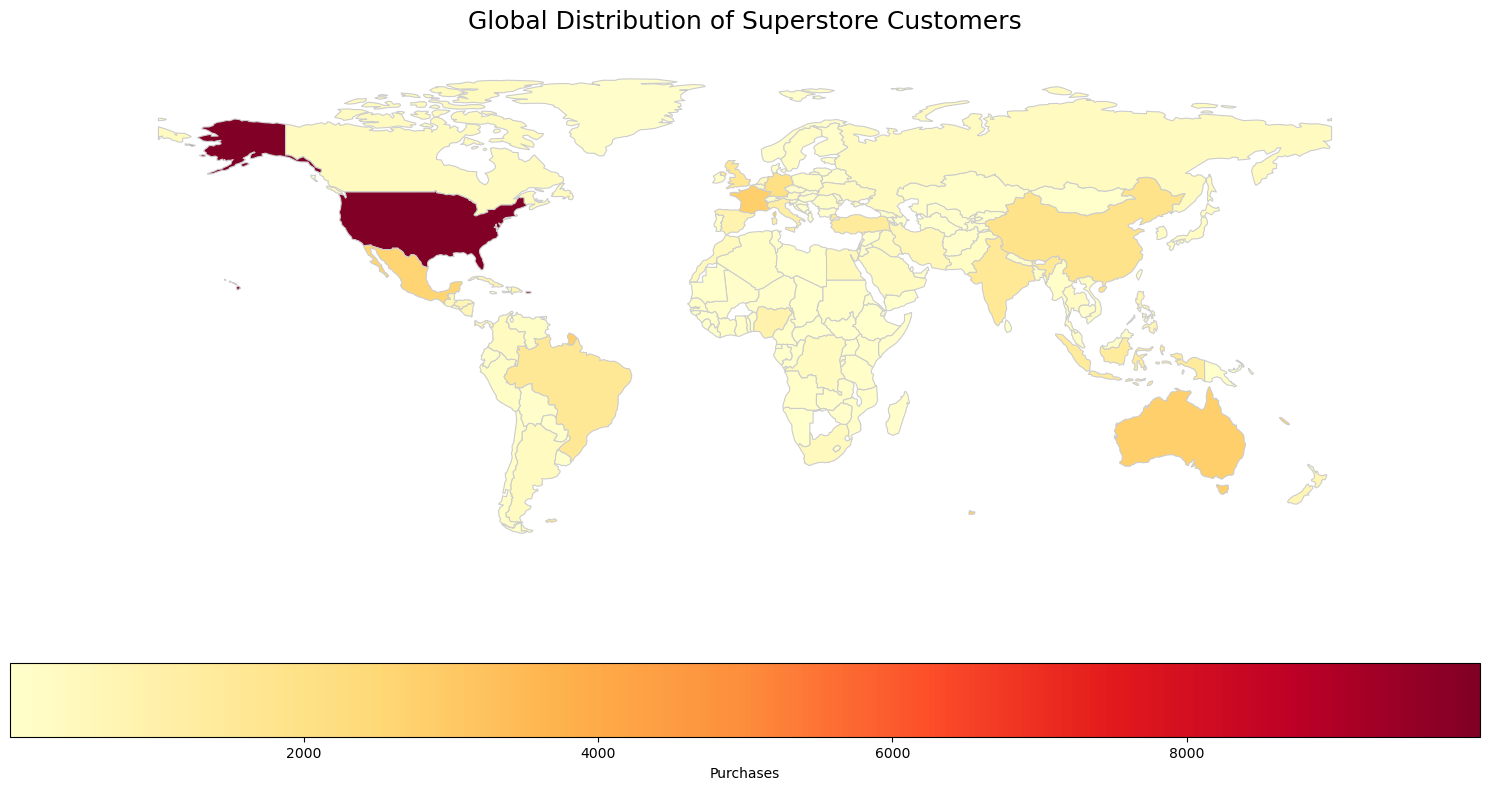

In [141]:
# Plot the heat map
fig, ax = plt.subplots(1, 1, figsize=(15, 8))
world_data.plot(
    column='Count',          # Column to color by
    cmap='YlOrRd',           # Color map
    linewidth=0.8,           # Border line width
    ax=ax,
    edgecolor='0.8',
    legend=True,
    legend_kwds={'label': "Purchases", 'orientation': "horizontal"}
)

# Add title
ax.set_title("Global Distribution of Superstore Customers", fontdict={'fontsize': 18}, pad=20)
ax.axis('off')  # Hide axis

# Save the plot as a png file
plt.tight_layout()
plt.savefig(r"C:\Users\raust\OneDrive\Documents\0BrainStation\BrainStation_DataScience\Week22_IndustrySprint2\Datasets\global_heatmap.png", dpi=300)
plt.show()

In [47]:
superstore_df["Sub.Category"].value_counts()

Sub.Category
Binders        6152
Storage        5059
Art            4883
Paper          3538
Chairs         3434
Phones         3357
Furnishings    3170
Accessories    3075
Labels         2606
Envelopes      2435
Supplies       2425
Fasteners      2420
Bookcases      2411
Copiers        2223
Appliances     1755
Machines       1486
Tables          861
Name: count, dtype: int64

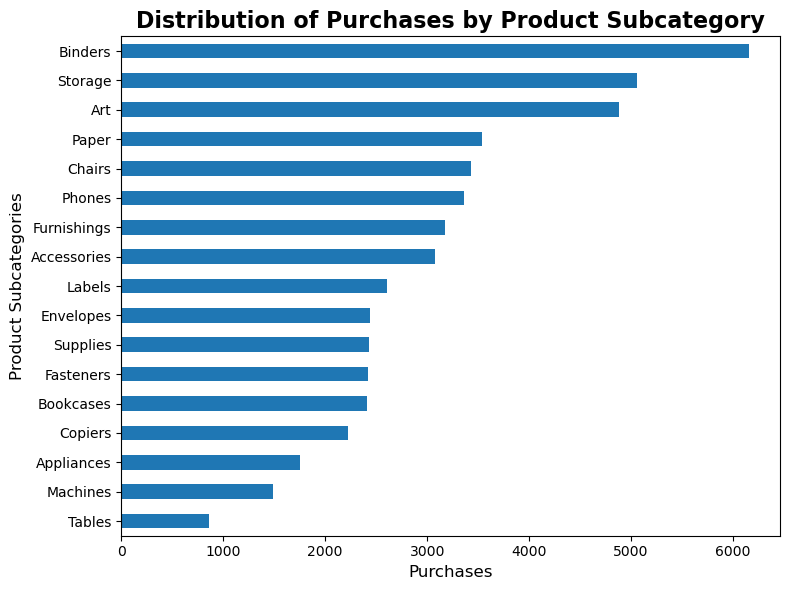

In [140]:
# Format the Product Sub-Category data for plotting
sub_category_counts = superstore_df["Sub.Category"].value_counts()
sub_category_counts_sorted = sub_category_counts.sort_values(ascending=True)

# Plot the data
sub_category_counts_sorted.plot(kind="barh");

# Add a title and axis labels
plt.title("Distribution of Purchases by Product Subcategory", fontsize=16, fontweight='bold')
plt.xlabel("Purchases", fontsize=12)
plt.ylabel("Product Subcategories", fontsize=12)

# Save the plot as a png file
plt.tight_layout()
plt.savefig(r"C:\Users\raust\OneDrive\Documents\0BrainStation\BrainStation_DataScience\Week22_IndustrySprint2\Datasets\purchase_distribution.png", dpi=300)